# Week 12 - Neural Networks
#### Part 2
### Notebook created by Jonathan Penava
By the end of this lesson you would have covered various concepts of Neural Networks.

## Overview
- Perceptrons
- <span style="color:red;">Coding a Perceptron</span>
- Number Example
- Tensor Flow

## Coding a Perceptron

Let's consider a simple example.  Look at the example below.  What is the output?

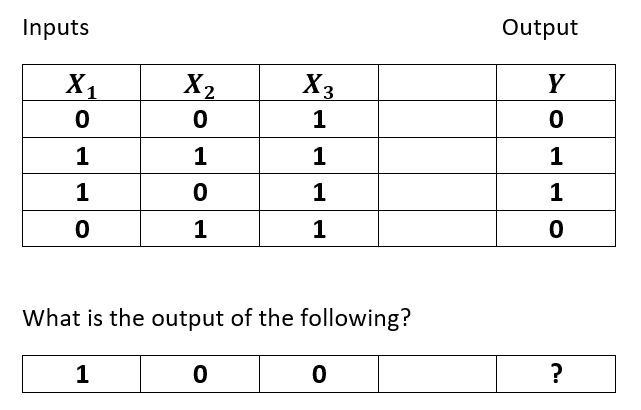

This is a relatively simple example.  The output is just the value of X1.  That means the answer should be 1.  We are going to code a Perceptron to make this prediction so that we can see what is going on.

In [1]:
import numpy as np

training_set_inputs = np.array([[0, 0, 1], [1, 1, 1], [1, 0, 1], [0, 1, 1]])

training_set_outputs = np.array([0, 1, 1, 0])

weights = [1, 1, 1]

#We are going to use the sigmoid activation function for this example
def sigmoid_function(z):
    return 1/(1+np.exp(-z))

We are now going to code a perceptron function.  We need our 3 inputs, and we also need our output so that we can measure our error and readjust our weights.

In [10]:
def perceptron(x1, x2, x3, output=0):
    #Sum of (X*W) of our inputs.
    sum = x1*weights[0] + x2*weights[1] + x3*weights[2] 
    #Apply our activation function.
    outputp = sigmoid_function(sum)
    #We need to readjust our weights so we are going to take
    #the difference of our expected output and our perceptron 
    #output and use it to adjust our weights.
    error = output-outputp
    weights[0] += x1*error
    weights[1] += x2*error
    weights[2] += x3*error
    #We return our perceptron's prediction
    return outputp

Now we need to train our perceptron.  We are going to pass in each of our inputs, and we are going to repeat that process 50 times.

In [11]:
for j in range(0, 50):
    for i in range(0, 4):
        x1 = training_set_inputs[i][0]
        x2 = training_set_inputs[i][1]
        x3 = training_set_inputs[i][2]
        o = training_set_outputs[i]
        perceptron(x1, x2, x3, o)
        #If you want to see what is happening to our
        #weights on each iteration and how they are 
        #changing, uncomment the print statement.
        #print(weights)

If we try to test our perceptron on our new data point

In [12]:
perceptron(1, 0, 0)

0.9994374471877403

Our perceptron is trending towards 1.  Note that Sigmoid will never be absolute 0 or 1.  If we look at our weights

In [13]:
print(weights)

[6.483025381539132, -0.40111401303027616, -3.331209608081024]


It likes X1, and doesn't like X2, or X3

## What is wrong with our model?

To start off we didn’t have a b.  This was done just to make our model simpler to read and understand.  We also included an error variable that was calculated by looking at the difference between our perceptron’s output and our expected output.  This is also referred to as the “Cost” of training our function.  The higher the cost the more our weights must be adjusted.  <br><br>
We used a relatively inefficient approach for calculating our cost, but we had a very simple example.  Calculating the cost of our training and using that cost to adjust our weights usually involves derivatives and gradients, which we won’t be covering here.  But hopefully you have an idea of what the cost of our function is, and that the idea is to minimize the cost.


## Forward Propagation vs Backpropagation

As we link Perceptrons together in a chain, we starting forming a neural network.

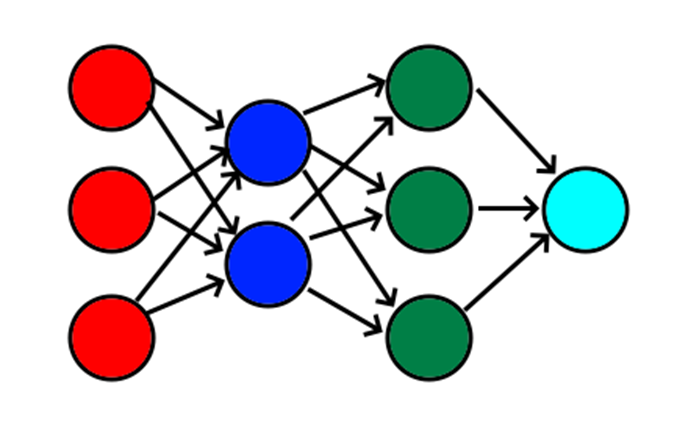

This forward propagation takes the output of one perceptron and feeds it as the input of the next perceptron.  <br><Br>
Backpropagation has us move backwards through our network, determining the weights on the inputs that would produce the output we wanted.  Using a variety of Calculus equations, we can use this backwards approach to minimize the costs in training our model. 
